In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import r2_score
import numpy as np

In [51]:
df = pd.read_csv(r"C:\Users\AROHI SINGH\OneDrive\Documents\newh.csv")
df.head(5)

,bedrooms,bathrooms,living area,lot area,floors,condition of the house,grade of the house,area,area of the basement,built Year,living_area_renov,lot_area_renov,number of schools nearby,distance from the airport,price
0,4,2.50,2920,4000,1.5,5,8,1910,1010,1909,2470,4000,2,51,1400000
1,5,2.75,2910,9480,1.5,3,8,2910,0,1939,2940,6600,1,53,1200000
2,4,2.50,3310,42998,2.0,3,9,3310,0,2001,3350,42847,3,76,838000
3,3,2.00,2710,4500,1.5,4,8,1880,830,1929,2060,4500,1,51,805000
4,3,2.50,2600,4750,1.0,4,9,1700,900,1951,2380,4750,1,67,790000


In [52]:
df['floors'] = df['floors'].astype(int)
df['bathrooms'] = df['bathrooms'].astype(int)
df.head(5)

,bedrooms,bathrooms,living area,lot area,floors,condition of the house,grade of the house,area,area of the basement,built Year,living_area_renov,lot_area_renov,number of schools nearby,distance from the airport,price
0,4,2,2920,4000,1,5,8,1910,1010,1909,2470,4000,2,51,1400000
1,5,2,2910,9480,1,3,8,2910,0,1939,2940,6600,1,53,1200000
2,4,2,3310,42998,2,3,9,3310,0,2001,3350,42847,3,76,838000
3,3,2,2710,4500,1,4,8,1880,830,1929,2060,4500,1,51,805000
4,3,2,2600,4750,1,4,9,1700,900,1951,2380,4750,1,67,790000


In [53]:
df.isnull().sum()
df = df.dropna()
df.head(5)

,bedrooms,bathrooms,living area,lot area,floors,condition of the house,grade of the house,area,area of the basement,built Year,living_area_renov,lot_area_renov,number of schools nearby,distance from the airport,price
0,4,2,2920,4000,1,5,8,1910,1010,1909,2470,4000,2,51,1400000
1,5,2,2910,9480,1,3,8,2910,0,1939,2940,6600,1,53,1200000
2,4,2,3310,42998,2,3,9,3310,0,2001,3350,42847,3,76,838000
3,3,2,2710,4500,1,4,8,1880,830,1929,2060,4500,1,51,805000
4,3,2,2600,4750,1,4,9,1700,900,1951,2380,4750,1,67,790000


In [54]:
df['price_per_sqft'] = (df['price'] / df['area']).round(2)
df['total_rooms'] = df['bedrooms'] + df['bathrooms']

In [55]:
df = df[df['price'] > 0]
df = df[df['price'] < df['price'].quantile(0.99)]
df = df[df['bedrooms'] > 0]

In [56]:
corr_matrix = df.corr(numeric_only=True)
print(corr_matrix['price'].sort_values(ascending=False))

price                        1.000000
living area                  0.690762
grade of the house           0.690147
living_area_renov            0.611937
area                         0.593450
price_per_sqft               0.545332
bathrooms                    0.483058
total_rooms                  0.455706
bedrooms                     0.317822
area of the basement         0.290842
floors                       0.260888
lot area                     0.090325
lot_area_renov               0.081493
built Year                   0.059026
condition of the house       0.042886
number of schools nearby     0.001732
distance from the airport    0.000680
Name: price, dtype: float64


In [66]:
X = df.drop('price', axis=1)
y = df['price']

# Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=20
)

In [59]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


In [60]:
rmse_scores = cross_val_score(model, X, y, cv=5, scoring='neg_mean_squared_error')
rmse = np.sqrt(-rmse_scores)

print("RMSE Scores:", rmse)
print("Average RMSE:", rmse.mean())

RMSE Scores: [88900.56258275 87652.3365664  84842.08627003 90556.24287555
 88930.1981611 ]
Average RMSE: 88176.28529116612


In [61]:

r2 = r2_score(y_test, y_pred)
print("R² Score:", r2)
accuracy = r2_score(y_test, y_pred) * 100
print("Accuracy:", accuracy, "%")

R² Score: 0.8929993737392022
Accuracy: 89.29993737392023 %


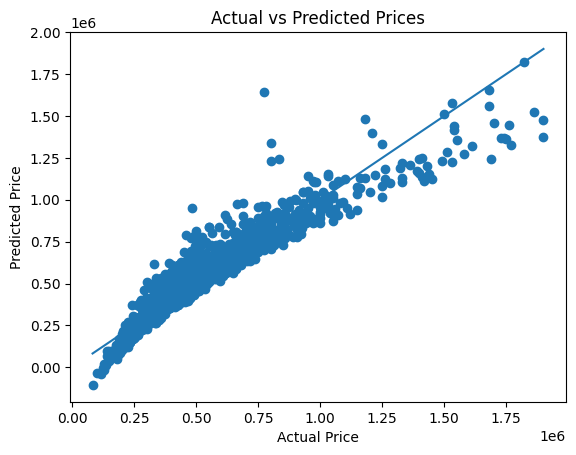

In [63]:
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")

# diagonal line (perfect prediction line)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])

plt.show()

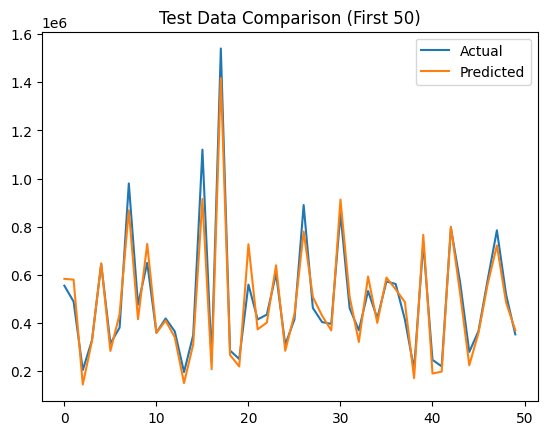

In [ ]:
import numpy as np

plt.figure()

# take first 50 samples
plt.plot(y_test.values[:50], label="Actual")
plt.plot(y_pred[:50], label="Predicted")

plt.legend()
plt.title("Test Data Comparison (First 50)")

plt.show()

In [65]:
#testing model

import numpy as np

#Index(['bedrooms', 'bathrooms', 'living area', 'lot area', 'floors',
    #    'condition of the house', 'grade of the house', 'area',
    #    'area of the basement', 'built Year', 'living_area_renov',
    #    'lot_area_renov', 'number of schools nearby',
    #    'distance from the airport', 'price_per_sqft', 'total_rooms'],
    #   dtype='object')
    
sample = np.array([[4,2,1820,5000,1.5,3,7,1640,180,1945,2060,5000,2,69,429,6]])

prediction = model.predict(sample)

print("Predicted Price:", round(prediction[0],2))

Predicted Price: 650849.38


c:\Users\AROHI SINGH\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
